Predicción meteorológica con gráfico
Los meteorólogos recopilan datos de humedad y presión atmosférica para predecir si lloverá o no.

Tu misión es construir un sistema inteligente que pueda predecir la probabilidad de lluvia utilizando un modelo de regresión logística.

🧩 Pasos a seguir

1. Crea la clase WeatherRecord

Esta clase representará un registro meteorológico individual, con:

humidity: humedad relativa en porcentaje (float)

pressure: presión atmosférica en hPa (float)

will_rain: 1 si lloverá, 0 si no (int)

Agrega un método to_vector(self) que devuelva una lista con [humidity, pressure].



2. Crea la clase WeatherDataGenerator

Esta clase generará datos sintéticos con la siguiente lógica:

Alta humedad y baja presión aumentan la probabilidad de lluvia.

Baja humedad y alta presión indican baja probabilidad de lluvia.

Implementa:

Un constructor que reciba el número de muestras (num_samples).

Un método generate() que devuelva una lista de WeatherRecord.

Puedes usar la fórmula siguiente para estimar la probabilidad de lluvia y aplicar la función sigmoide

rain_prob = (humidity - 50) * 0.03 - (pressure - 1010) * 0.02
rain_prob = 1 / (1 + np.exp(-rain_prob))
Convierte estas probabilidades en 0 o 1 usando un umbral de 0.5.



3. Crea la clase WeatherRainClassifier

Esta clase entrenará un modelo de regresión logística con scikit-learn.

Implementa:

fit(records): entrena el modelo a partir de una lista de WeatherRecord.

predict(humidity, pressure): devuelve 0 o 1 según la predicción.

evaluate(records): imprime matriz de confusión y reporte de clasificación.



4. Crea la clase WeatherRainPredictionExample

Esta clase representará el flujo completo de uso.

Implementa un método run() que:

Genere datos usando WeatherDataGenerator.

Divida los datos en entrenamiento y prueba.

Entrene un modelo con WeatherRainClassifier.

Evalúe el modelo con los datos de prueba.

Haga una predicción para condiciones nuevas (ej. humedad = 80, presión = 995).

Muestre un gráfico (matplotlib) de los datos de prueba, coloreando según si llovió o no.



🎯 Ejemplo de uso

example = WeatherRainPredictionExample()
example.run()


📊 Salida esperada

[[21  0]
 [ 0 39]]
              precision    recall  f1-score   support
 
           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        39
 
    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60
 
🔍 Predicción para condiciones nuevas:
   Humedad: 80%
   Presión: 995 hPa
   ¿Lloverá?: Sí ☔






Practicar con numpy para generar datos sintéticos, con regresión logística para realizar predicciones y pandas con matplotlib para graficar los datos obtenidos.

 # Solucion

Evaluación del modelo con datos de prueba:
Matriz de Confusión:
[[17  0]
 [ 0 43]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        43

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60


🔍 Predicción para condiciones nuevas:
   Humedad: 80%
   Presión: 995 hPa
   ¿Lloverá?: Sí ☔



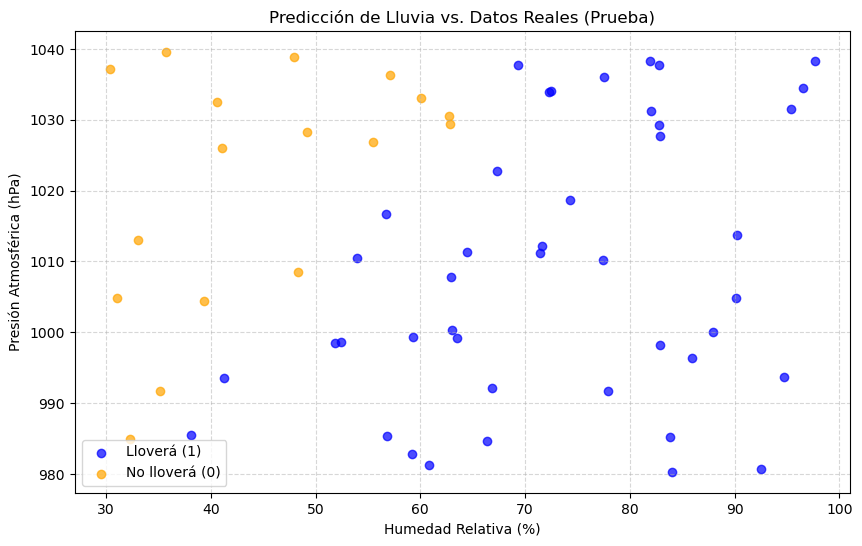

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

class WeatherRecord:
    def __init__(self, humidity, pressure, will_rain):
        self.humidity = humidity
        self.pressure = pressure
        self.will_rain = will_rain

    def to_vector(self):
        return [self.humidity, self.pressure]

class WeatherDataGenerator:
    def __init__(self, num_samples):
        self.num_samples = num_samples

    def generate(self):
        records = []
        for _ in range(self.num_samples):
            humidity = np.random.uniform(30, 100)
            pressure = np.random.uniform(980, 1040)
            
            linear_combination = (humidity - 50) * 0.03 - (pressure - 1010) * 0.02
            rain_prob = 1 / (1 + np.exp(-linear_combination))
            
            will_rain = 1 if rain_prob >= 0.5 else 0
            
            records.append(WeatherRecord(humidity, pressure, will_rain))
        return records

class WeatherRainClassifier:
    def __init__(self):
        self.model = LogisticRegression()

    def fit(self, records):
        X = [record.to_vector() for record in records]
        y = [record.will_rain for record in records]
        self.model.fit(X, y)

    def predict(self, humidity, pressure):
        new_data = np.array([[humidity, pressure]])
        return self.model.predict(new_data)[0]

    def evaluate(self, records):
        X_test = [record.to_vector() for record in records]
        y_test = [record.will_rain for record in records]
        
        y_pred = self.model.predict(X_test)
        
        print("Matriz de Confusión:")
        print(confusion_matrix(y_test, y_pred))
        
        print("\nReporte de Clasificación:")
        print(classification_report(y_test, y_pred))

class WeatherRainPredictionExample:

    def run(self):
        generator = WeatherDataGenerator(num_samples=200)
        all_data = generator.generate()
        
        train_data, test_data = train_test_split(all_data, test_size=60, random_state=42)
        
        classifier = WeatherRainClassifier()
        classifier.fit(train_data)
        
        print("Evaluación del modelo con datos de prueba:")
        classifier.evaluate(test_data)
        
        humidity_new = 80
        pressure_new = 995
        prediction = classifier.predict(humidity_new, pressure_new)
        
        prediction_text = "Sí ☔" if prediction == 1 else "No ☀️"
        
        print("\n🔍 Predicción para condiciones nuevas:")
        print(f"   Humedad: {humidity_new}%")
        print(f"   Presión: {pressure_new} hPa")
        print(f"   ¿Lloverá?: {prediction_text}\n")
        
        self.plot_data(test_data)

    def plot_data(self, test_records):
        df = pd.DataFrame([
            {"humidity": r.humidity, "pressure": r.pressure, "will_rain": r.will_rain}
            for r in test_records
        ])
        
        rain = df[df["will_rain"] == 1]
        no_rain = df[df["will_rain"] == 0]
        
        plt.figure(figsize=(10, 6))
        plt.scatter(rain["humidity"], rain["pressure"], c="blue", label="Lloverá (1)", alpha=0.7)
        plt.scatter(no_rain["humidity"], no_rain["pressure"], c="orange", label="No lloverá (0)", alpha=0.7)
        
        plt.title("Predicción de Lluvia vs. Datos Reales (Prueba)")
        plt.xlabel("Humedad Relativa (%)")
        plt.ylabel("Presión Atmosférica (hPa)")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()

if __name__ == "__main__":
    example = WeatherRainPredictionExample()
    example.run()

Casos de prueba

Suspenso: O, Aprobado: 1 de 1 pruebas

test_model_prediction